# EDA — Datos EEG OpenBCI
**16 canales · 125 Hz · 48 participantes**

Secciones:
1. Setup y carga
2. Resumen global del dataset
3. Duración por participante
4. Calidad de señal — saturación
5. Señal cruda — visualización
6. PSD (Densidad Espectral de Potencia)
7. Potencia por bandas EEG
8. Distribución de amplitud por canal
9. Correlación entre canales
10. SNR proxy por participante

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 4)

# ── Parámetros globales ──────────────────────────────────────────────────────
DATA_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Datos EEG')
FS         = 125          # Hz
SAT_THRESH = 90_000       # µV — umbral de saturación / electrodo desconectado
EEG_COLS   = [f'EXG Channel {i}' for i in range(16)]
# Nombres 10-20 — orden OpenBCI Cyton+Daisy 16ch
CH_NAMES   = ['Fp1','Fp2','C3','C4','P7','P8','O1','O2',
               'F7','F8','F3','F4','T7','T8','P3','P4']
BANDS      = {'Delta':(1,4), 'Theta':(4,8), 'Alpha':(8,13),
               'Beta':(13,30), 'Gamma':(30,45)}

print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: /Users/marioromero/Tesis_MDS/EDA/Datos EEG


In [3]:
# ── Funciones auxiliares ─────────────────────────────────────────────────────

def list_files():
    return sorted(glob.glob(os.path.join(DATA_DIR, 'P*.txt')))

def load_eeg(fpath):
    df = pd.read_csv(fpath, comment='%', skipinitialspace=True)
    df.columns = df.columns.str.strip()
    return df

def pid(fpath):
    return os.path.basename(fpath).replace('.txt', '')

def sat_pct(series):
    return (series.abs() > SAT_THRESH).mean() * 100

def good_cols(df):
    """Devuelve (ch_name, col) donde saturación < 1%."""
    return [(ch, col) for ch, col in zip(CH_NAMES, EEG_COLS) if sat_pct(df[col]) < 1]

def band_power(psd, freqs):
    return {b: np.trapz(psd[(freqs>=lo)&(freqs<=hi)], freqs[(freqs>=lo)&(freqs<=hi)])
            for b,(lo,hi) in BANDS.items()}

files = list_files()
print(f'{len(files)} archivos encontrados')

48 archivos encontrados


---
## 1 · Carga y resumen global

In [4]:
rows = []
for fpath in files:
    df = load_eeg(fpath)
    sat = {ch: sat_pct(df[col]) for ch, col in zip(CH_NAMES, EEG_COLS)}
    rows.append({
        'participant'     : pid(fpath),
        'n_samples'       : len(df),
        'duration_min'    : len(df) / FS / 60,
        'n_nan'           : df[EEG_COLS].isna().sum().sum(),
        'n_sat_channels'  : sum(v == 100.0 for v in sat.values()),
        **{f'sat_{ch}': v for ch, v in sat.items()},
    })

meta = pd.DataFrame(rows)
print(f'Shape: {meta.shape}')
meta[['participant','n_samples','duration_min','n_nan','n_sat_channels']].head(10)

Shape: (48, 21)


,participant,n_samples,duration_min,n_nan,n_sat_channels
0,P01,102091,13.612133,0,6
1,P02,115474,15.396533,0,1
2,P03,98578,13.143733,0,1
3,P04,88012,11.734933,0,0
4,P05,94527,12.603600,0,0
5,P06,118307,15.774267,0,0
6,P07,103333,13.777733,0,2
7,P08,119475,15.930000,0,0
8,P09,98652,13.153600,0,1
9,P10,93063,12.408400,0,2


In [5]:
print('=== Resumen global ===')
print(f"N participantes : {len(meta)}")
print(f"Duración mín    : {meta.duration_min.min():.1f} min  ({meta.loc[meta.duration_min.idxmin(),'participant']})")
print(f"Duración máx    : {meta.duration_min.max():.1f} min  ({meta.loc[meta.duration_min.idxmax(),'participant']})")
print(f"Duración mediana: {meta.duration_min.median():.1f} min")
print(f"Duración media  : {meta.duration_min.mean():.1f} ± {meta.duration_min.std():.1f} min")
print(f"NaN totales     : {meta.n_nan.sum()}")
print(f"Part. con ≥1 canal saturado: {(meta.n_sat_channels > 0).sum()}/{len(meta)}")

=== Resumen global ===
N participantes : 48
Duración mín    : 10.9 min  (P23)
Duración máx    : 17.3 min  (P29)
Duración mediana: 13.1 min
Duración media  : 13.4 ± 1.5 min
NaN totales     : 0
Part. con ≥1 canal saturado: 21/48


---
## 2 · Duración de grabación por participante

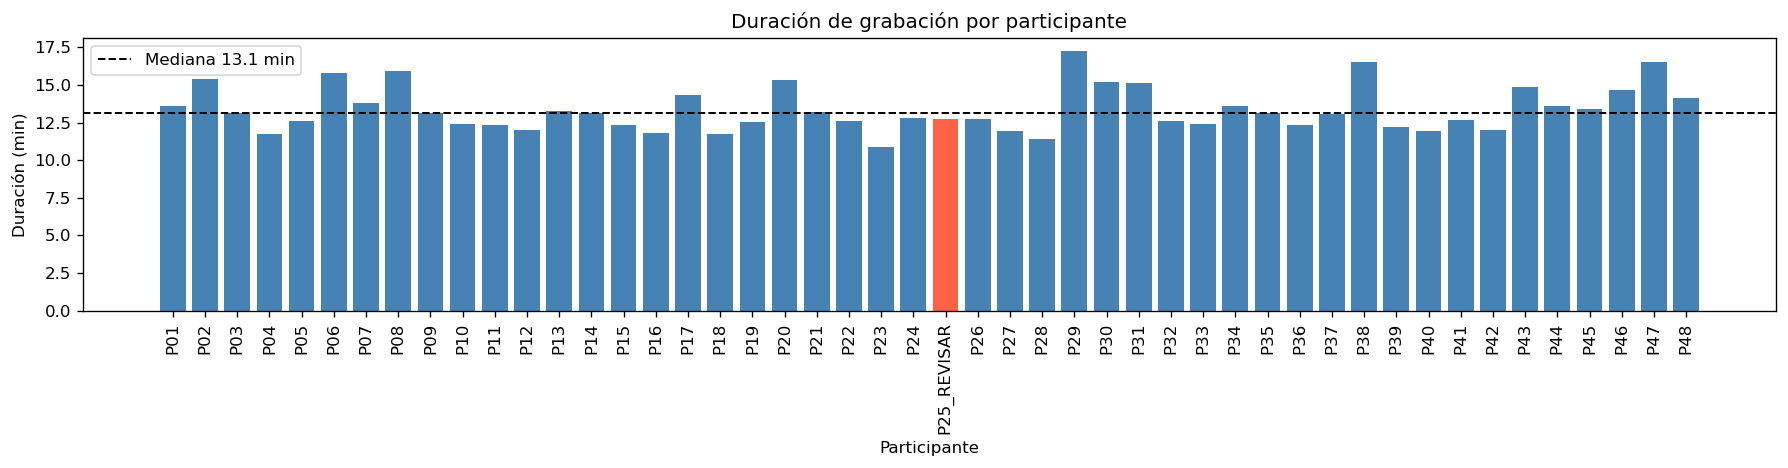

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
colors = ['tomato' if 'REVISAR' in p else 'steelblue' for p in meta['participant']]
ax.bar(meta['participant'], meta['duration_min'], color=colors)
ax.axhline(meta['duration_min'].median(), color='k', ls='--', lw=1.2,
           label=f"Mediana {meta['duration_min'].median():.1f} min")
ax.set_xlabel('Participante'); ax.set_ylabel('Duración (min)')
ax.set_title('Duración de grabación por participante')
ax.tick_params(axis='x', rotation=90); ax.legend()
plt.tight_layout(); plt.show()

---
## 3 · Calidad de señal — saturación de canales
Valores `|µV| > 90 000` indican electrodo desconectado o saturación del amplificador.

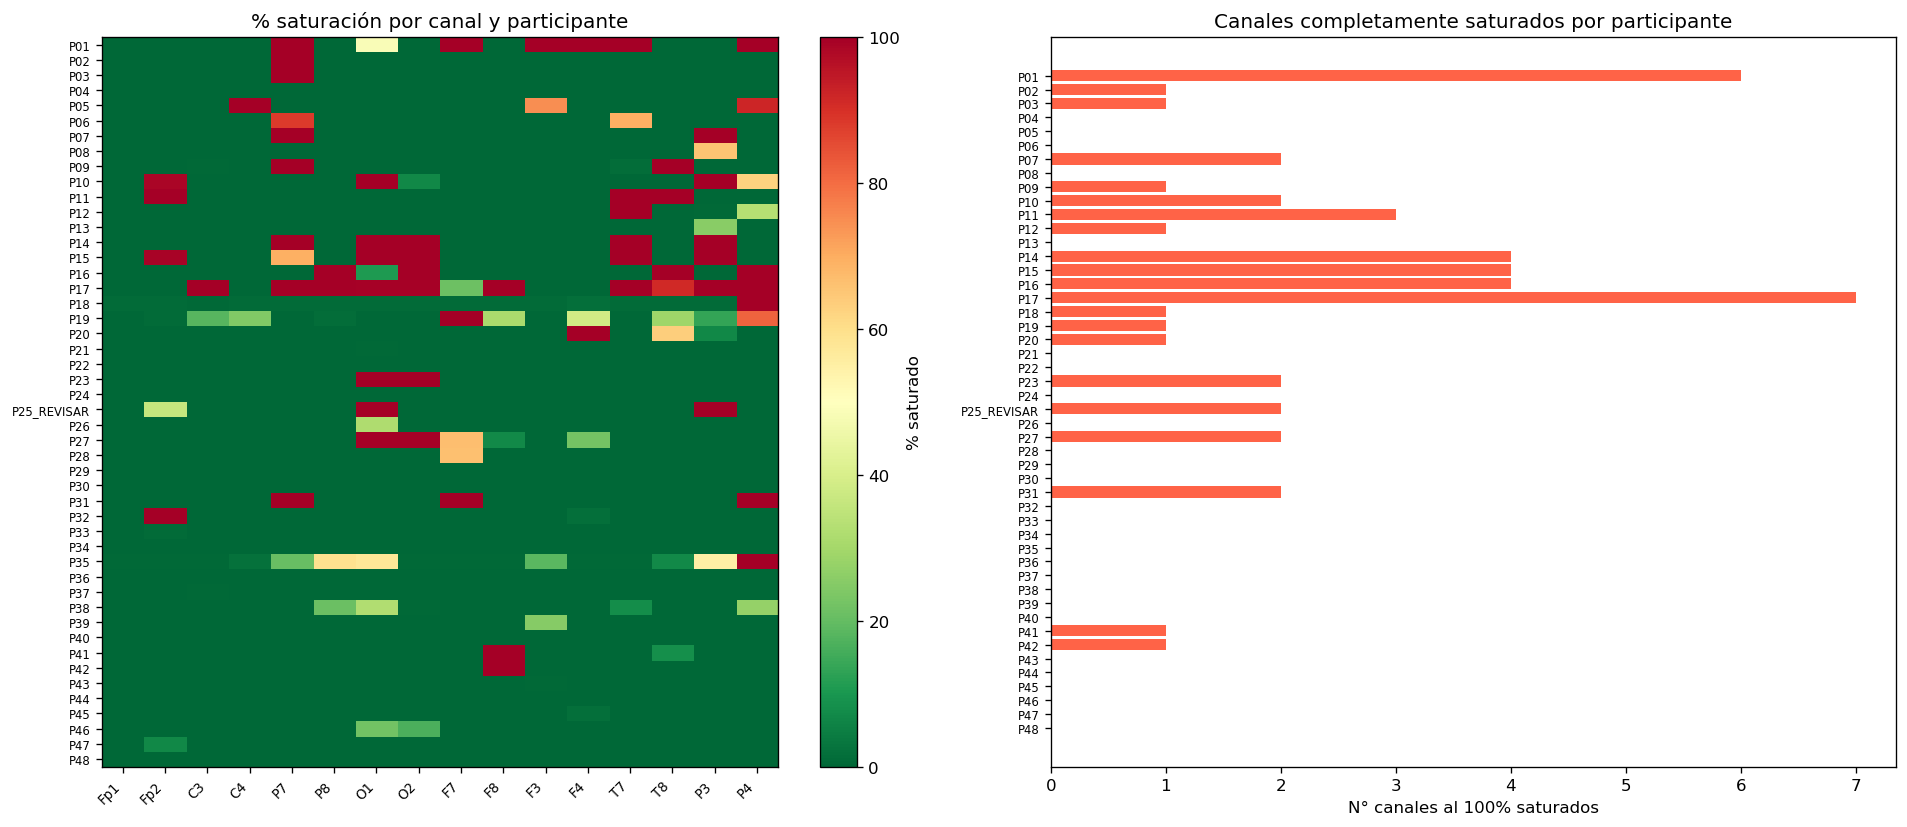

In [7]:
sat_cols   = [f'sat_{ch}' for ch in CH_NAMES]
sat_matrix = meta[sat_cols].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im = axes[0].imshow(sat_matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
axes[0].set_xticks(range(16)); axes[0].set_xticklabels(CH_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(len(meta))); axes[0].set_yticklabels(meta['participant'], fontsize=7)
axes[0].set_title('% saturación por canal y participante')
plt.colorbar(im, ax=axes[0], label='% saturado')

axes[1].barh(meta['participant'], meta['n_sat_channels'], color='tomato')
axes[1].set_xlabel('N° canales al 100% saturados')
axes[1].set_title('Canales completamente saturados por participante')
axes[1].invert_yaxis(); axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout(); plt.show()

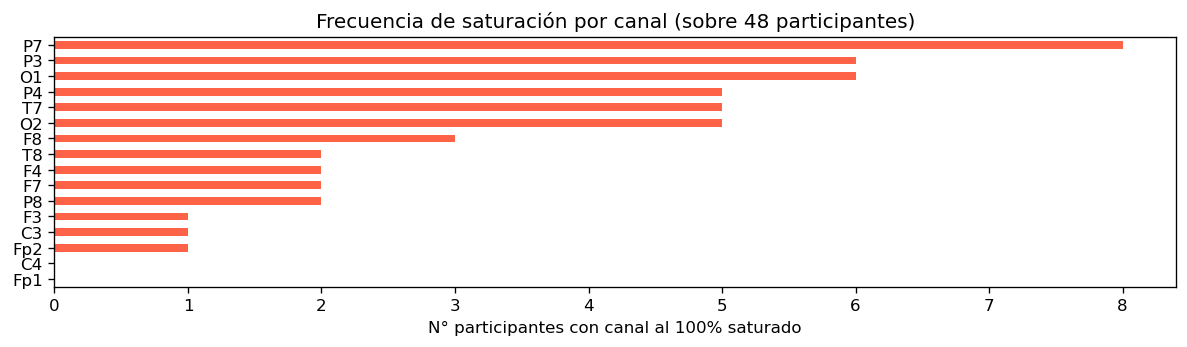

P7     8
O1     6
P3     6
O2     5
T7     5
P4     5
F8     3
P8     2
F7     2
F4     2
T8     2
Fp2    1
C3     1
F3     1
Fp1    0
C4     0
dtype: int64


In [8]:
# Canales más problemáticos
sat_freq = (meta[sat_cols] == 100).sum()
sat_freq.index = CH_NAMES
fig, ax = plt.subplots(figsize=(10, 3))
sat_freq.sort_values().plot.barh(ax=ax, color='tomato')
ax.set_xlabel('N° participantes con canal al 100% saturado')
ax.set_title('Frecuencia de saturación por canal (sobre 48 participantes)')
plt.tight_layout(); plt.show()
print(sat_freq.sort_values(ascending=False))

---
## 4 · Señal cruda — visualización temporal
Cambia `TARGET_PID` para ver otro participante.

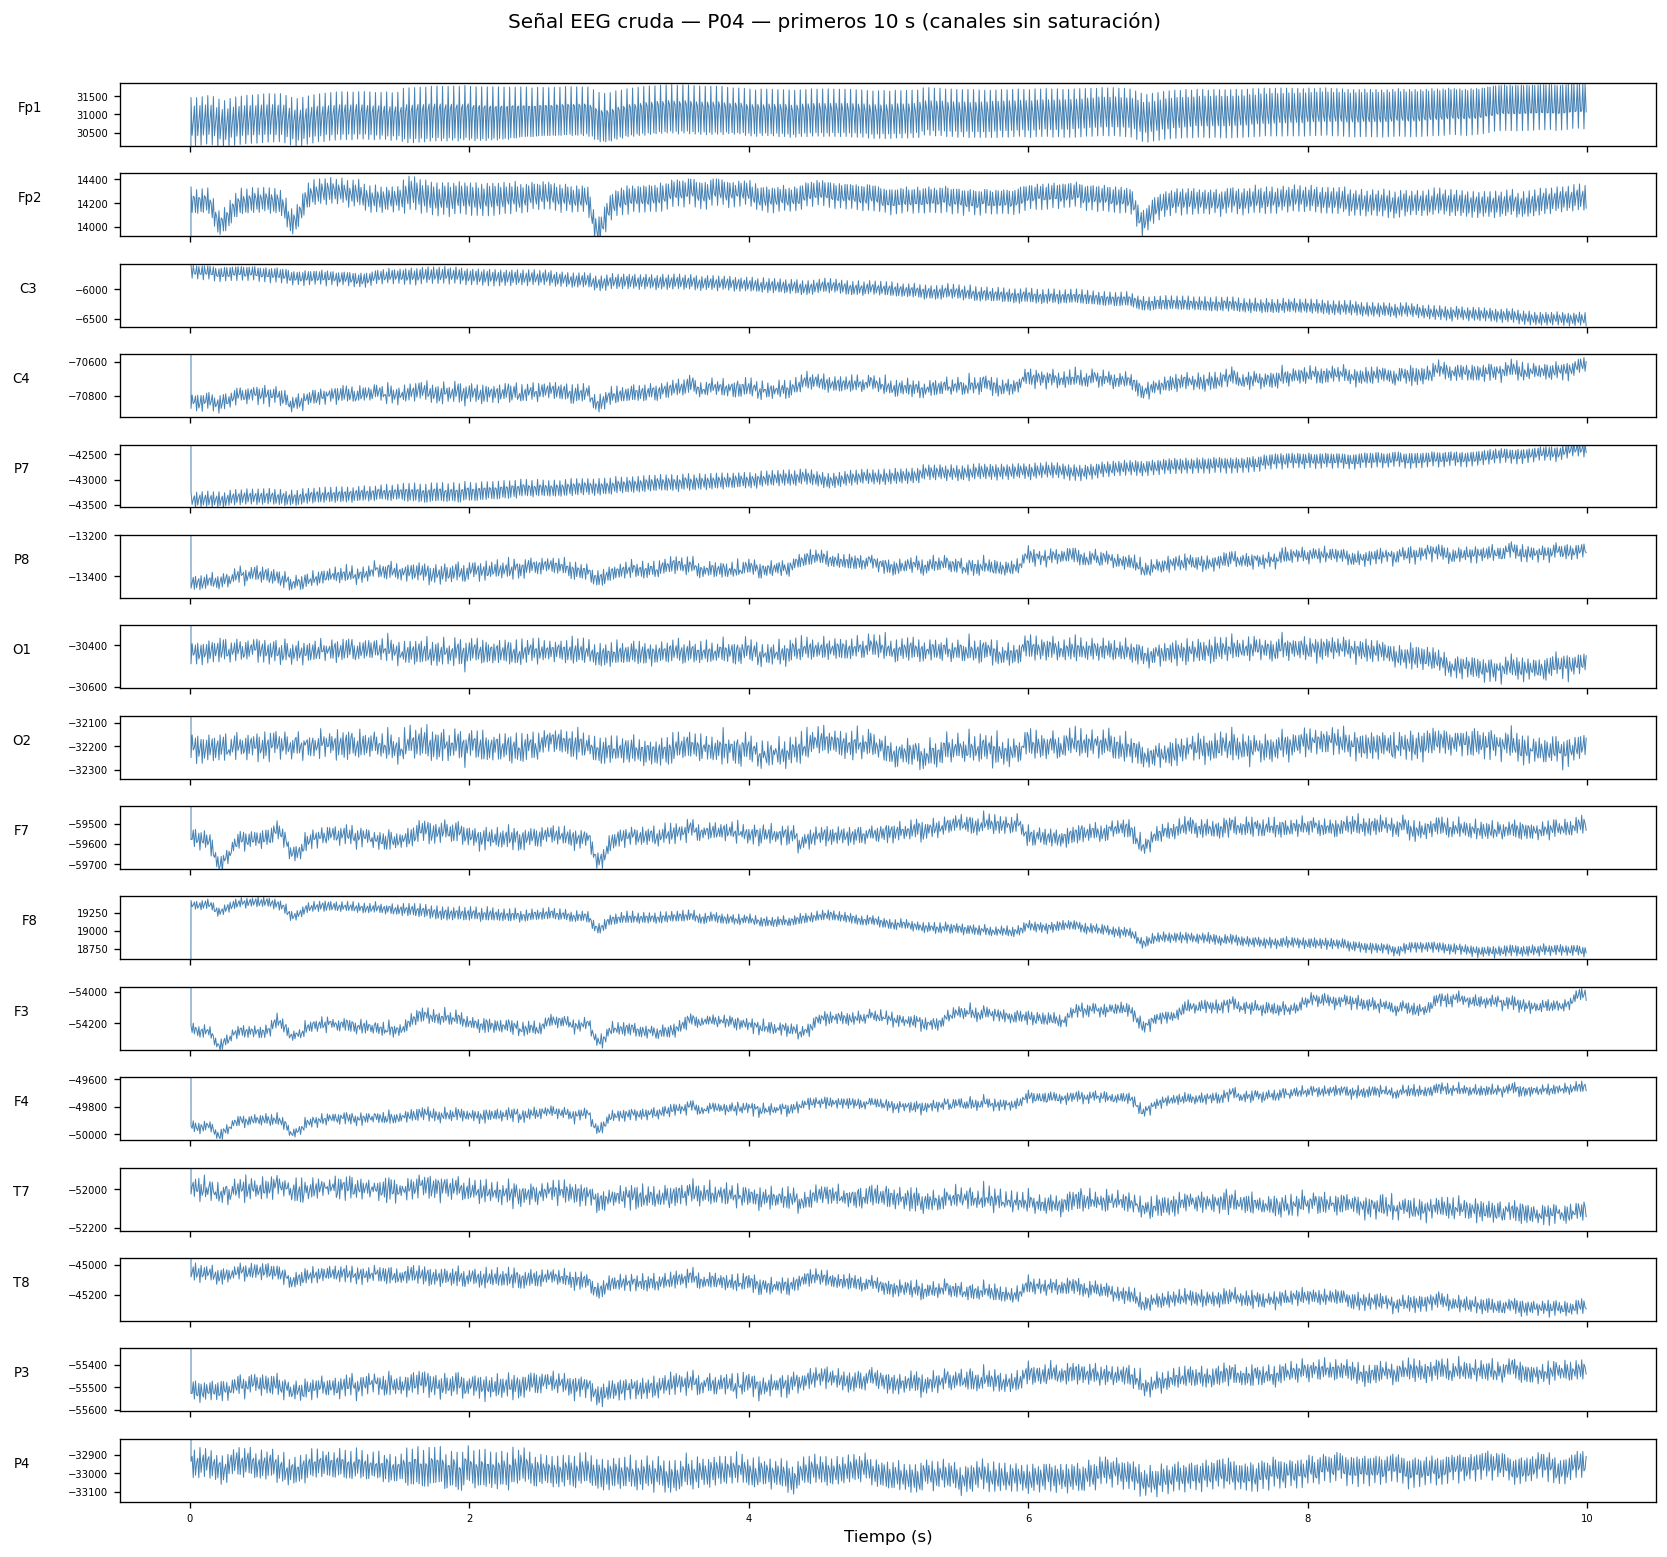

In [9]:
TARGET_PID = 'P04'   # <-- cambia aquí
SECONDS    = 10      # segundos a mostrar

fpath_ex = next(f for f in files if pid(f) == TARGET_PID)
df_ex    = load_eeg(fpath_ex)
n_show   = FS * SECONDS
t        = np.arange(n_show) / FS
good     = good_cols(df_ex)

fig, axes = plt.subplots(len(good), 1, figsize=(14, max(5, len(good)*0.8)), sharex=True)
if len(good) == 1: axes = [axes]
for ax, (ch, col) in zip(axes, good):
    sig = df_ex[col].values[:n_show]
    ax.plot(t, sig, lw=0.6, color='steelblue')
    ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=28)
    ax.tick_params(labelsize=6)
    ax.set_ylim(np.percentile(sig,1)-50, np.percentile(sig,99)+50)
axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle(f'Señal EEG cruda — {TARGET_PID} — primeros {SECONDS} s (canales sin saturación)', y=1.01)
plt.tight_layout(); plt.show()

---
## 5 · PSD — Densidad Espectral de Potencia (Welch)

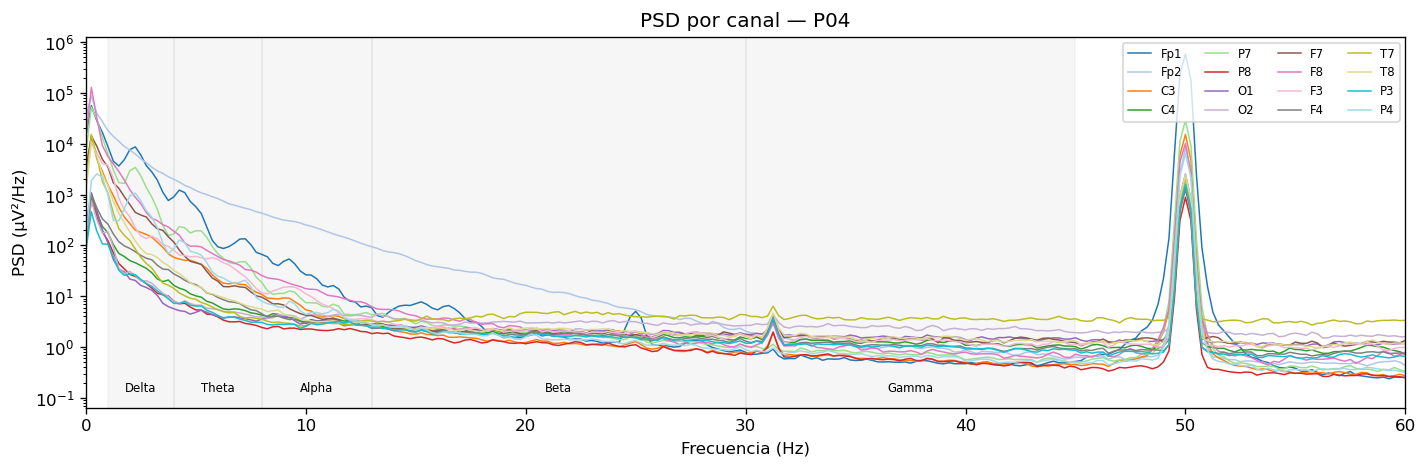

In [10]:
# Un participante específico
TARGET_PID_PSD = 'P04'  # <-- cambia aquí

fpath_p  = next(f for f in files if pid(f) == TARGET_PID_PSD)
df_p     = load_eeg(fpath_p)
good_p   = good_cols(df_p)

fig, ax = plt.subplots(figsize=(12, 4))
colors_ch = plt.cm.tab20(np.linspace(0, 1, len(good_p)))
for (ch, col), c in zip(good_p, colors_ch):
    sig = df_p[col].values.astype(float)
    freqs, psd = sp_signal.welch(sig, fs=FS, nperseg=FS*4)
    ax.semilogy(freqs, psd, lw=0.9, label=ch, color=c)

for bname, (lo, hi) in BANDS.items():
    ax.axvspan(lo, hi, alpha=0.07, color='gray')
    ax.text((lo+hi)/2, ax.get_ylim()[0]*2, bname, ha='center', fontsize=7)

ax.set_xlim(0, 60); ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title(f'PSD por canal — {TARGET_PID_PSD}')
ax.legend(ncol=4, fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()

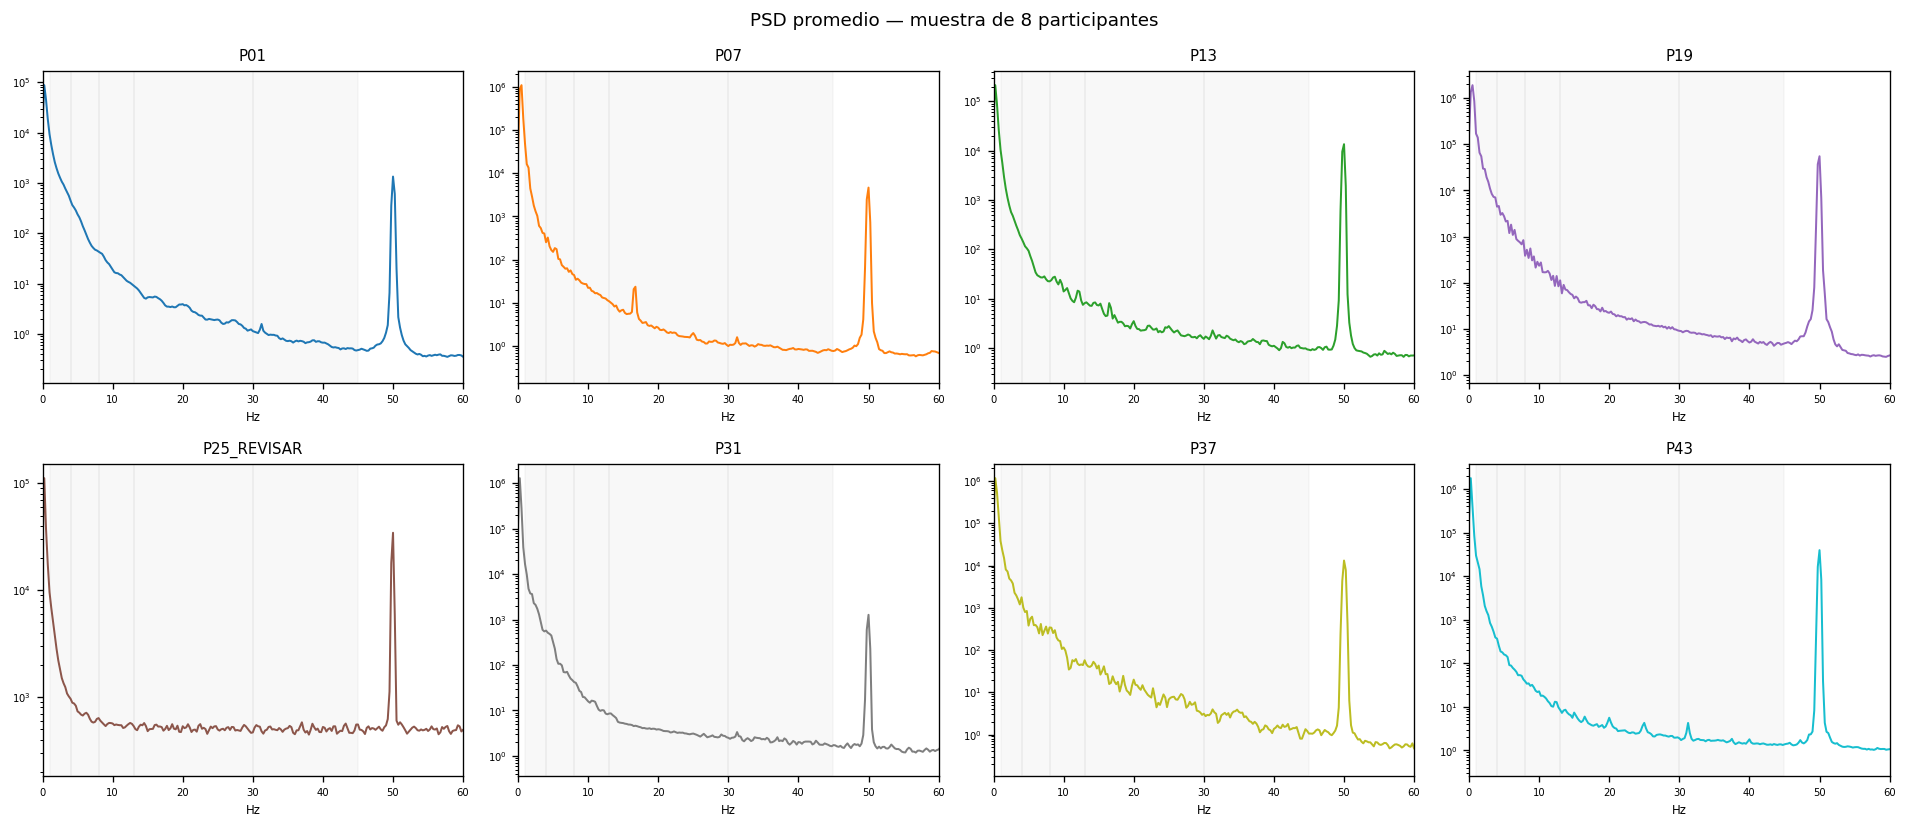

In [11]:
# PSD promedio (todos los canales buenos) — muestra de participantes
step = max(1, len(files) // 8)
sample_files = files[::step][:8]
colors_p = plt.cm.tab10(np.linspace(0, 1, len(sample_files)))

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()
for idx, (fpath, color) in enumerate(zip(sample_files, colors_p)):
    p = pid(fpath)
    df_p = load_eeg(fpath)
    good_p = good_cols(df_p)
    if not good_p: continue
    psds = []
    for ch, col in good_p:
        freqs, psd = sp_signal.welch(df_p[col].values.astype(float), fs=FS, nperseg=FS*4)
        psds.append(psd)
    axes[idx].semilogy(freqs, np.mean(psds, axis=0), color=color, lw=1.2)
    axes[idx].set_xlim(0, 60); axes[idx].set_title(p, fontsize=9)
    axes[idx].set_xlabel('Hz', fontsize=7); axes[idx].tick_params(labelsize=6)
    for bname,(lo,hi) in BANDS.items():
        axes[idx].axvspan(lo, hi, alpha=0.05, color='gray')
for ax in axes[len(sample_files):]:
    ax.set_visible(False)
fig.suptitle('PSD promedio — muestra de 8 participantes', fontsize=11)
plt.tight_layout(); plt.show()

---
## 6 · Potencia por banda EEG — todos los participantes

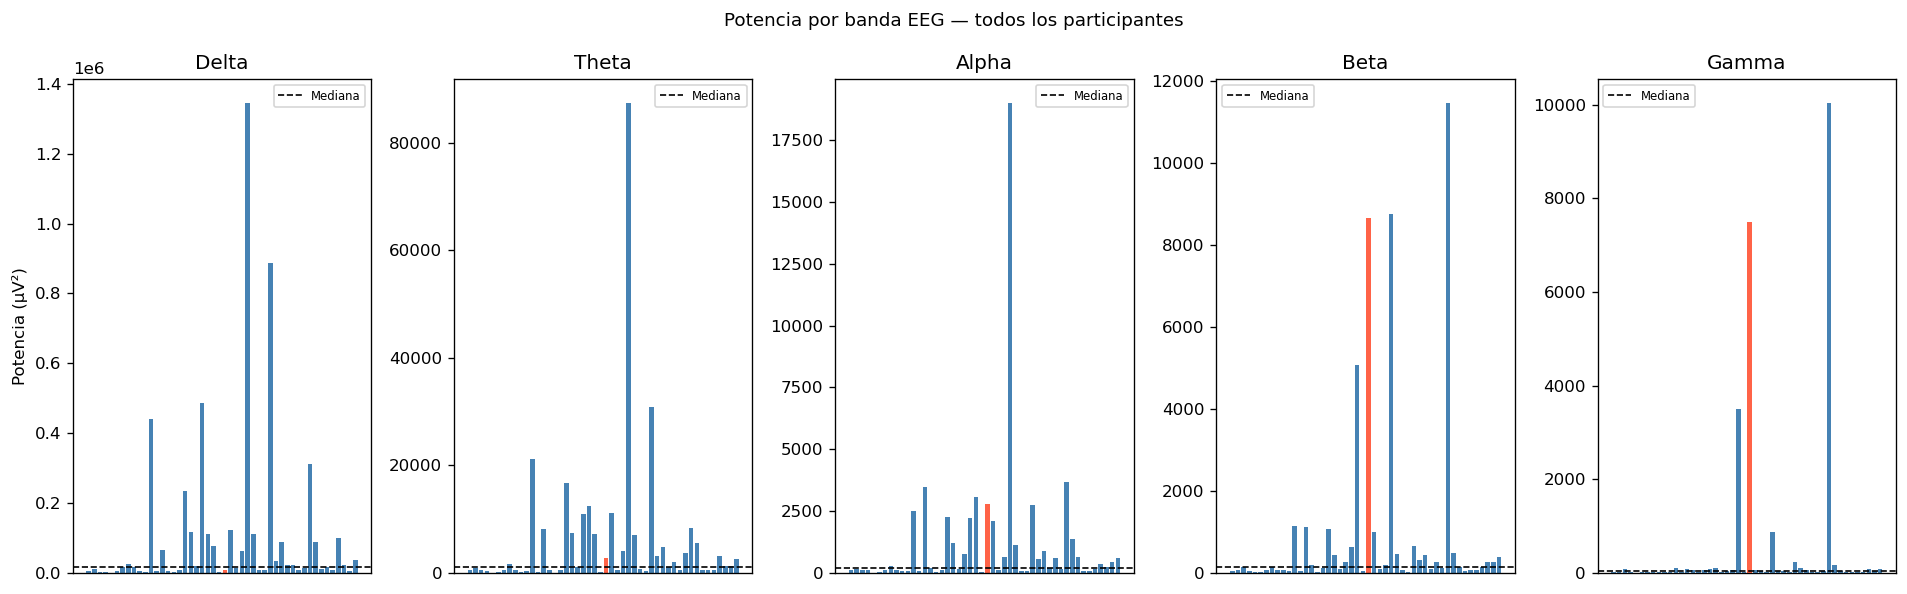


Medianas:
Delta    1.68e+04
Theta    1.18e+03
Alpha    2.21e+02
Beta     1.41e+02
Gamma    3.60e+01
dtype: object


In [12]:
band_rows = []
for fpath in files:
    p   = pid(fpath)
    df_p = load_eeg(fpath)
    good_p = good_cols(df_p)
    if not good_p:
        band_rows.append({'participant': p, **{b: np.nan for b in BANDS}})
        continue
    all_psds = []
    for ch, col in good_p:
        freqs, psd = sp_signal.welch(df_p[col].values.astype(float), fs=FS, nperseg=FS*4)
        all_psds.append(psd)
    mean_psd = np.mean(all_psds, axis=0)
    band_rows.append({'participant': p, **band_power(mean_psd, freqs)})

band_df = pd.DataFrame(band_rows)

fig, axes = plt.subplots(1, len(BANDS), figsize=(16, 5))
for ax, bname in zip(axes, BANDS):
    vals  = band_df[bname].dropna()
    parts = band_df.loc[band_df[bname].notna(), 'participant']
    bcolors = ['tomato' if 'REVISAR' in p else 'steelblue' for p in parts]
    ax.bar(range(len(vals)), vals.values, color=bcolors, edgecolor='none')
    ax.axhline(vals.median(), color='k', ls='--', lw=1, label='Mediana')
    ax.set_title(bname); ax.legend(fontsize=7)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.set_ylabel('Potencia (µV²)' if bname=='Delta' else '')
fig.suptitle('Potencia por banda EEG — todos los participantes', fontsize=11)
plt.tight_layout(); plt.show()

print('\nMedianas:')
print(band_df[list(BANDS)].median().apply(lambda x: f'{x:.2e}'))

---
## 7 · Distribución de amplitud por canal (boxplot)

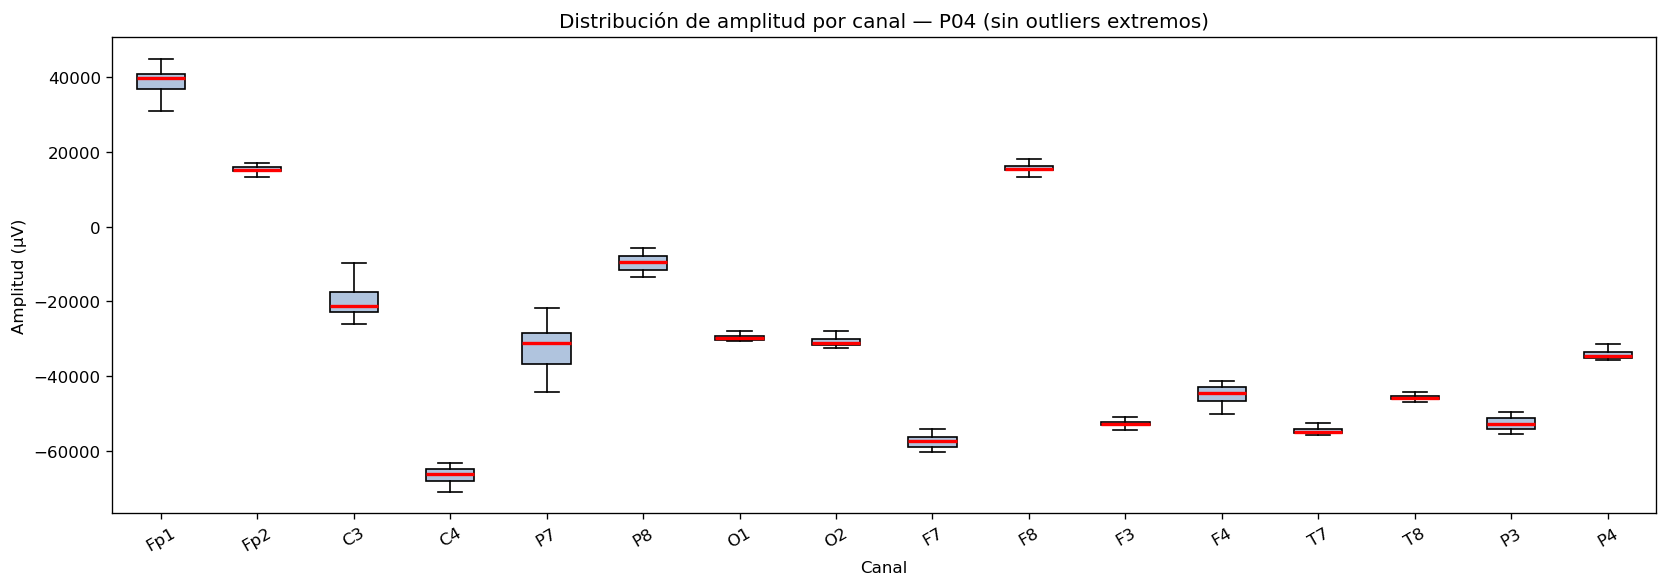

In [13]:
TARGET_PID_BOX = 'P04'  # <-- elige un participante sin saturaciones

fpath_b = next(f for f in files if pid(f) == TARGET_PID_BOX)
df_b    = load_eeg(fpath_b)
good_b  = good_cols(df_b)

data_bp  = [df_b[col].values for ch, col in good_b]
labels_b = [ch for ch, col in good_b]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_bp, tick_labels=labels_b, showfliers=False, patch_artist=True,
                medianprops=dict(color='red', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.set_xlabel('Canal'); ax.set_ylabel('Amplitud (µV)')
ax.set_title(f'Distribución de amplitud por canal — {TARGET_PID_BOX} (sin outliers extremos)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

---
## 8 · Correlación entre canales

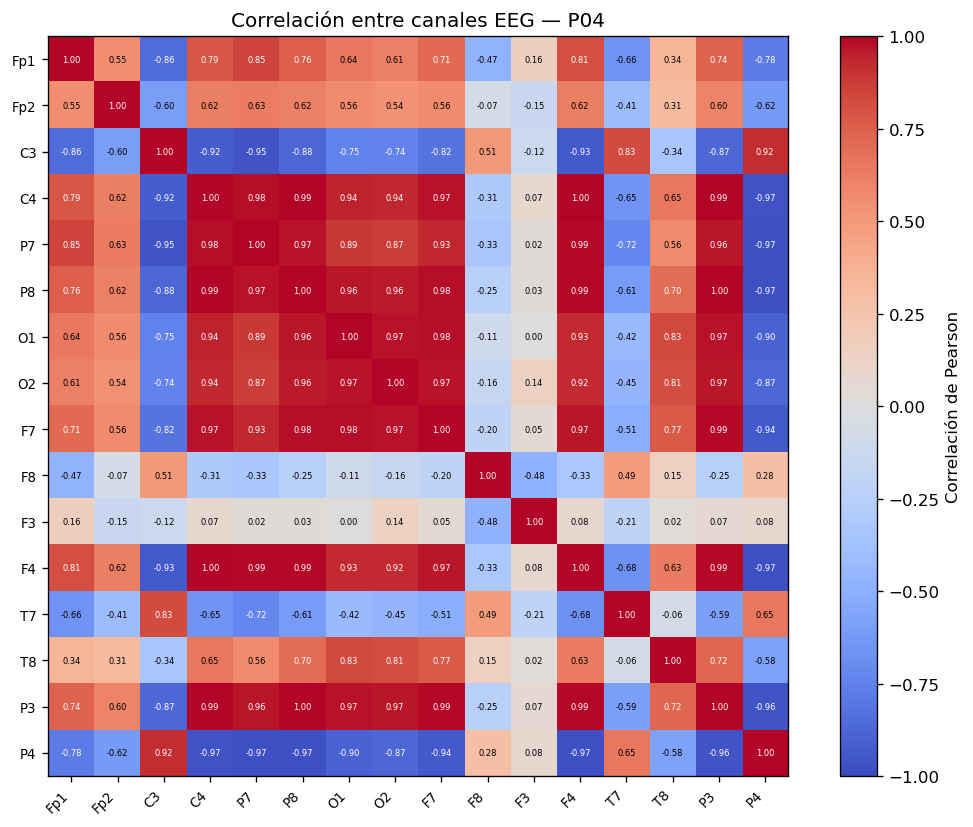

In [14]:
TARGET_PID_CORR = 'P04'  # <-- cambia aquí

fpath_c = next(f for f in files if pid(f) == TARGET_PID_CORR)
df_c    = load_eeg(fpath_c)
good_c  = good_cols(df_c)

cols_c  = [col for ch, col in good_c]
names_c = [ch  for ch, col in good_c]
corr    = df_c[cols_c].corr()
corr.index = corr.columns = names_c

fig, ax = plt.subplots(figsize=(9, 7))
im2 = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(names_c))); ax.set_xticklabels(names_c, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(names_c))); ax.set_yticklabels(names_c, fontsize=8)
plt.colorbar(im2, ax=ax, label='Correlación de Pearson')
ax.set_title(f'Correlación entre canales EEG — {TARGET_PID_CORR}')
for i in range(len(names_c)):
    for j in range(len(names_c)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center',
                fontsize=5, color='black' if abs(corr.iloc[i,j])<0.7 else 'white')
plt.tight_layout(); plt.show()

---
## 9 · SNR proxy — todos los participantes
`SNR proxy = std(señal) / std(diff(señal))`  
Canales saturados se marcan como NaN.

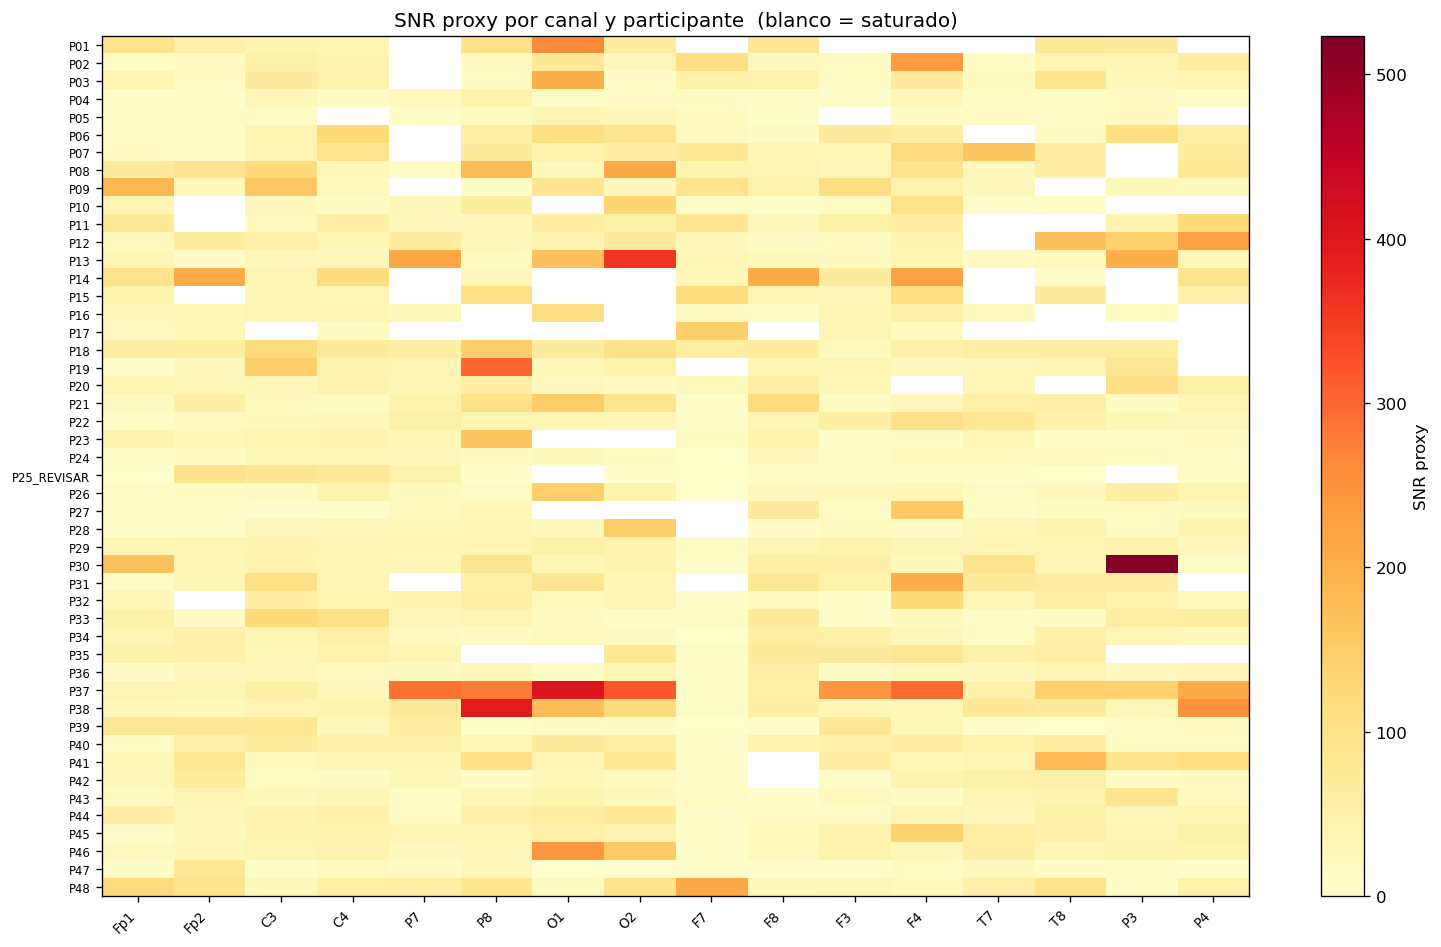

In [15]:
snr_rows = []
for fpath in files:
    p    = pid(fpath)
    df_p = load_eeg(fpath)
    row  = {'participant': p}
    for ch, col in zip(CH_NAMES, EEG_COLS):
        sig = df_p[col].values.astype(float)
        if sat_pct(df_p[col]) > 50:
            row[ch] = np.nan
        else:
            row[ch] = sig.std() / (np.diff(sig).std() + 1e-9)
    snr_rows.append(row)

snr_df     = pd.DataFrame(snr_rows)
snr_matrix = snr_df[CH_NAMES].values

fig, ax = plt.subplots(figsize=(13, 8))
im3 = ax.imshow(snr_matrix, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(16)); ax.set_xticklabels(CH_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(meta))); ax.set_yticklabels(meta['participant'], fontsize=7)
ax.set_title('SNR proxy por canal y participante  (blanco = saturado)')
plt.colorbar(im3, ax=ax, label='SNR proxy')
plt.tight_layout(); plt.show()

---
## 10 · Exportar resumen
Guarda los metadatos y potencias por banda como CSV.

In [16]:
meta.to_csv('meta_participantes.csv', index=False)
band_df.to_csv('potencia_bandas.csv', index=False)
snr_df.to_csv('snr_canales.csv', index=False)
print('Guardados: meta_participantes.csv, potencia_bandas.csv, snr_canales.csv')

# Vista rápida final
display(meta[['participant','duration_min','n_sat_channels']].describe())

Guardados: meta_participantes.csv, potencia_bandas.csv, snr_canales.csv


,duration_min,n_sat_channels
count,48.000000,48.000000
mean,13.378178,1.020833
std,1.485483,1.630684
min,10.896000,0.000000
25%,12.351433,0.000000
50%,13.108467,0.000000
75%,14.174267,1.250000
max,17.263600,7.000000
